# FRE-GT-9743 Assignment 8 — Complete Solution

This notebook is self-contained. It uses `T = 1.0` for the final quantile-map question, reflecting the update from the professor.

In [1]:
# Cell 1: Imports and display helpers
import numpy as np
import pandas as pd
from scipy.stats import norm, qmc
from scipy.optimize import brentq, minimize
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)

def as_table(d):
    return pd.DataFrame(list(d.items()), columns=['Metric', 'Value'])


In [2]:
# Cell 2: Black-76 and Bachelier utilities

def black76_price(F, K, T, sigma, option='call'):
    F, K = float(F), float(K)
    if T <= 0:
        return max(F-K, 0.0) if option == 'call' else max(K-F, 0.0)
    if sigma <= 0:
        return max(F-K, 0.0) if option == 'call' else max(K-F, 0.0)
    volT = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / volT
    d2 = d1 - volT
    if option == 'call':
        return F * norm.cdf(d1) - K * norm.cdf(d2)
    return K * norm.cdf(-d2) - F * norm.cdf(-d1)

def bachelier_price(F, K, T, sigma_n, option='call'):
    if T <= 0:
        return max(F-K, 0.0) if option == 'call' else max(K-F, 0.0)
    if sigma_n <= 0:
        return max(F-K, 0.0) if option == 'call' else max(K-F, 0.0)
    sT = sigma_n * np.sqrt(T)
    d = (F - K) / sT
    if option == 'call':
        return (F-K) * norm.cdf(d) + sT * norm.pdf(d)
    return (K-F) * norm.cdf(-d) + sT * norm.pdf(d)

def implied_lognormal_from_normal(F, K, T, sigma_n):
    option = 'put' if F > K else 'call'
    target = bachelier_price(F, K, T, sigma_n, option)
    f = lambda s: black76_price(F, K, T, s, option) - target
    return brentq(f, 1e-12, 10.0)

def implied_normal_from_lognormal(F, K, T, sigma_ln):
    option = 'put' if F > K else 'call'
    target = black76_price(F, K, T, sigma_ln, option)
    f = lambda s: bachelier_price(F, K, T, s, option) - target
    return brentq(f, 1e-12, 10.0)


In [3]:
# Cell 3: Hagan SABR lognormal implied volatility and conversions

def sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu):
    if F <= 0 or K <= 0:
        raise ValueError('Shifted F and K must be positive.')
    if alpha <= 0 or nu < 0 or not (0 <= beta <= 1) or abs(rho) >= 1:
        raise ValueError('Invalid SABR parameters.')
    one_minus_beta = 1.0 - beta
    FK = F * K
    L = np.log(F / K)
    A = alpha / FK**(one_minus_beta / 2.0)
    w1 = 1.0 + (one_minus_beta**2 / 24.0) * L**2 + (one_minus_beta**4 / 1920.0) * L**4
    w2 = ((one_minus_beta**2 / 24.0) * alpha**2 / FK**one_minus_beta
          + 0.25 * rho * beta * nu * alpha / FK**(one_minus_beta / 2.0)
          + ((2.0 - 3.0 * rho**2) / 24.0) * nu**2)
    if abs(L) < 1e-12 or nu == 0:
        z_over_x = 1.0
    else:
        z = (nu / alpha) * FK**(one_minus_beta / 2.0) * L
        xz = np.log((np.sqrt(1.0 - 2.0*rho*z + z*z) + z - rho) / (1.0 - rho))
        z_over_x = z / xz
    return A * z_over_x * w1 * (1.0 + w2 * T)

def alpha_from_atm_lognormal_vol(F, T, sigma_atm_ln, beta, rho, nu):
    def objective(a):
        return sabr_lognormal_vol(F, F, T, a, beta, rho, nu) - sigma_atm_ln
    lo, hi = 1e-12, max(1.0, 10.0 * sigma_atm_ln * F**(1-beta))
    while objective(hi) < 0:
        hi *= 2.0
    return brentq(objective, lo, hi, xtol=1e-13, rtol=1e-13)

def alpha_from_atm_normal_vol(F, T, sigma_atm_n, beta, rho, nu):
    sigma_ln = implied_lognormal_from_normal(F, F, T, sigma_atm_n)
    return alpha_from_atm_lognormal_vol(F, T, sigma_ln, beta, rho, nu)

def fd_greek(func, x, h=None):
    h = h or max(1e-6, abs(x)*1e-5)
    if x - h <= 0:
        return (func(x+h) - func(x)) / h
    return (func(x+h) - func(x-h)) / (2*h)


In [4]:
# Cell 4: Problem 1 — SABR conversion and risk examples
s = 0.04
F = 0.04
K = 0.042
T = 0.5
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
Fs, Ks = F+s, K+s

ln_vol = sabr_lognormal_vol(Fs, Ks, T, alpha, beta, rho, nu)
alpha_back = alpha_from_atm_lognormal_vol(Fs, T, sabr_lognormal_vol(Fs, Fs, T, alpha, beta, rho, nu), beta, rho, nu)
normal_atm = implied_normal_from_lognormal(Fs, Fs, T, sabr_lognormal_vol(Fs, Fs, T, alpha, beta, rho, nu))
alpha_from_n = alpha_from_atm_normal_vol(Fs, T, normal_atm, beta, rho, nu)

risk = {
    'sigma_LN(K)': ln_vol,
    'ATM sigma_N': normal_atm,
    'alpha backed from ATM sigma_LN': alpha_back,
    'alpha backed from ATM sigma_N': alpha_from_n,
    'd alpha / d sigma_LN_ATM': fd_greek(lambda sig: alpha_from_atm_lognormal_vol(Fs, T, sig, beta, rho, nu), sabr_lognormal_vol(Fs, Fs, T, alpha, beta, rho, nu)),
    'd alpha / d beta': fd_greek(lambda b: alpha_from_atm_lognormal_vol(Fs, T, sabr_lognormal_vol(Fs, Fs, T, alpha, beta, rho, nu), b, rho, nu), beta),
    'd alpha / d nu': fd_greek(lambda n: alpha_from_atm_lognormal_vol(Fs, T, sabr_lognormal_vol(Fs, Fs, T, alpha, beta, rho, nu), beta, rho, n), nu),
    'd alpha / d rho': fd_greek(lambda r: alpha_from_atm_lognormal_vol(Fs, T, sabr_lognormal_vol(Fs, Fs, T, alpha, beta, rho, nu), beta, r, nu), rho),
    'd alpha / d F': fd_greek(lambda f: alpha_from_atm_lognormal_vol(f+s, T, sabr_lognormal_vol(Fs, Fs, T, alpha, beta, rho, nu), beta, rho, nu), F),
}
as_table(risk)


,Metric,Value
0,sigma_LN(K),0.307536
1,ATM sigma_N,0.024422
2,alpha backed from ATM sigma_LN,0.110000
3,alpha backed from ATM sigma_N,0.110000
4,d alpha / d sigma_LN_ATM,0.357411
5,d alpha / d beta,0.276975
6,d alpha / d nu,-0.004035
7,d alpha / d rho,0.000464
8,d alpha / d F,0.550000


In [5]:
# Cell 5: Problem 1 — European call/put SABR risks under ATM normal-vol parameterization

def sabr_option_from_atm_normal(F, K, T, option, atm_normal_sigma, beta, rho, nu, shift=0.0):
    Fs = F + shift
    Ks = K + shift
    a = alpha_from_atm_normal_vol(Fs, T, atm_normal_sigma, beta, rho, nu)
    sigma_ln_K = sabr_lognormal_vol(Fs, Ks, T, a, beta, rho, nu)
    return black76_price(Fs, Ks, T, sigma_ln_K, option)

atm_normal_sigma = normal_atm
base_call = sabr_option_from_atm_normal(F, K, T, 'call', atm_normal_sigma, beta, rho, nu, s)
base_put = sabr_option_from_atm_normal(F, K, T, 'put', atm_normal_sigma, beta, rho, nu, s)

def option_risks(option):
    f = lambda FF: sabr_option_from_atm_normal(FF, K, T, option, atm_normal_sigma, beta, rho, nu, s)
    k = lambda KK: sabr_option_from_atm_normal(F, KK, T, option, atm_normal_sigma, beta, rho, nu, s)
    vn = lambda sig: sabr_option_from_atm_normal(F, K, T, option, sig, beta, rho, nu, s)
    b = lambda bb: sabr_option_from_atm_normal(F, K, T, option, atm_normal_sigma, bb, rho, nu, s)
    rr = lambda r: sabr_option_from_atm_normal(F, K, T, option, atm_normal_sigma, beta, r, nu, s)
    nn = lambda n: sabr_option_from_atm_normal(F, K, T, option, atm_normal_sigma, beta, rho, n, s)
    return {
        'PV': sabr_option_from_atm_normal(F, K, T, option, atm_normal_sigma, beta, rho, nu, s),
        'Delta': fd_greek(f, F),
        'Gamma': (f(F+1e-5)-2*f(F)+f(F-1e-5))/(1e-5**2),
        'Strike risk': fd_greek(k, K),
        'dPV/dsigmaN_ATM': fd_greek(vn, atm_normal_sigma),
        'dPV/dbeta': fd_greek(b, beta),
        'dPV/drho': fd_greek(rr, rho),
        'dPV/dnu': fd_greek(nn, nu),
    }

pd.concat({'Call': as_table(option_risks('call')).set_index('Metric'),
           'Put': as_table(option_risks('put')).set_index('Metric')}, axis=1)


,Call,Put
,Value,Value
Metric,,
PV,0.006058,0.008058
Delta,0.392273,-0.607727
Gamma,22.813290,22.813290
Strike risk,-0.392903,0.607097
dPV/dsigmaN_ATM,0.282303,0.282303
dPV/dbeta,0.000086,0.000086
dPV/drho,0.000137,0.000137
dPV/dnu,0.000148,0.000148


In [6]:
# Cell 6: Problem 2 — detect negative density in the lower wing
alpha2 = 0.0512
beta2 = 0.5
nu2 = 0.322
rho2 = -9.5/100
shift2 = 0.0
forward2 = 3.54/100
tte2 = 10.0

def sabr_call_price(K):
    sig = sabr_lognormal_vol(forward2+shift2, K+shift2, tte2, alpha2, beta2, rho2, nu2)
    return black76_price(forward2+shift2, K+shift2, tte2, sig, 'call')

# Breeden-Litzenberger: pdf(K) = second derivative of call wrt strike.
# The lower strike region is checked on a dense grid.
K_grid = np.linspace(0.0005, 0.06, 500)
C = np.array([sabr_call_price(k) for k in K_grid])
dC = np.gradient(C, K_grid)
pdf_numeric = np.gradient(dC, K_grid)
neg_idx = np.where(pdf_numeric < -1e-6)[0]
summary_density = {
    'minimum density': pdf_numeric.min(),
    'first negative strike': K_grid[neg_idx[0]] if len(neg_idx) else np.nan,
    'last negative strike': K_grid[neg_idx[-1]] if len(neg_idx) else np.nan,
    'number of negative grid points': len(neg_idx),
}
as_table(summary_density)


,Metric,Value
0,minimum density,-451.885683
1,first negative strike,0.000500
2,last negative strike,0.005866
3,number of negative grid points,46.000000


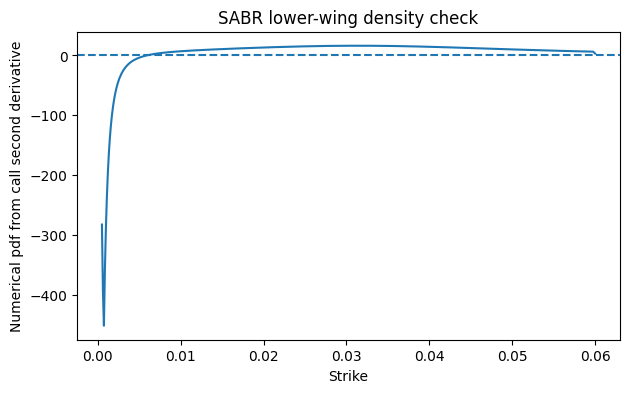

In [7]:
# Cell 7: Problem 2 plot
plt.figure(figsize=(7, 4))
plt.plot(K_grid, pdf_numeric)
plt.axhline(0.0, linestyle='--')
plt.title('SABR lower-wing density check')
plt.xlabel('Strike')
plt.ylabel('Numerical pdf from call second derivative')
plt.show()


In [8]:
# Cell 8: Problem 3 — SABR simulation and density convergence

def simulate_sabr_terminal(F0, T, alpha, beta, rho, nu, n_steps=200, n_paths=20000, seed=7):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    F = np.full(n_paths, F0, dtype=float)
    sigma = np.full(n_paths, alpha, dtype=float)
    for _ in range(n_steps):
        z1 = rng.standard_normal(n_paths)
        z2 = rng.standard_normal(n_paths)
        dW1 = sqrt_dt * z1
        dW2 = sqrt_dt * (rho*z1 + np.sqrt(1-rho*rho)*z2)
        F = np.maximum(F + sigma * np.maximum(F, 1e-12)**beta * dW1, 1e-12)
        sigma = sigma * np.exp(nu*dW2 - 0.5*nu*nu*dt)
    return F

def analytic_density_from_calls(F0, T, alpha, beta, rho, nu, lo, hi, n=401):
    grid = np.linspace(lo, hi, n)
    prices = np.array([black76_price(F0, k, T, sabr_lognormal_vol(F0, k, T, alpha, beta, rho, nu), 'call') for k in grid])
    pdf = np.gradient(np.gradient(prices, grid), grid)
    pdf = np.maximum(pdf, 0)
    area = np.trapz(pdf, grid)
    if area > 0:
        pdf /= area
    cdf = np.cumsum(pdf * np.gradient(grid))
    cdf = np.clip(cdf / cdf[-1], 0, 1)
    return grid, pdf, cdf

F3, T3, alpha3, beta3, rho3, nu3 = 0.04, 1.0, 0.035, 0.5, -0.25, 0.35
x_grid3, pdf3, cdf3 = analytic_density_from_calls(F3, T3, alpha3, beta3, rho3, nu3, 0.0001, 0.12)
rows = []
for n_paths in [5_000, 20_000, 80_000]:
    terminal = simulate_sabr_terminal(F3, T3, alpha3, beta3, rho3, nu3, n_steps=250, n_paths=n_paths, seed=42)
    rows.append({'paths': n_paths, 'sample mean': terminal.mean(), 'sample std': terminal.std(), 'P(S_T <= F0)': np.mean(terminal <= F3)})
pd.DataFrame(rows)


/tmp/ipykernel_2584/3684278569.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, grid)


,paths,sample mean,sample std,P(S_T <= F0)
0,5000,0.040006,0.007277,0.502000
1,20000,0.039957,0.007205,0.500450
2,80000,0.039990,0.007181,0.498862


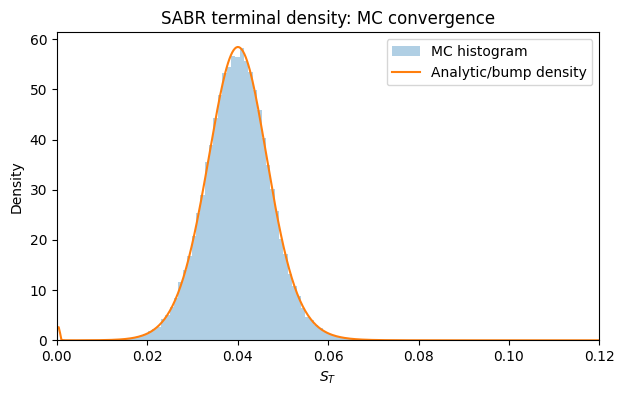

In [9]:
# Cell 9: Problem 3 plot: analytic pdf vs Monte Carlo histogram
terminal = simulate_sabr_terminal(F3, T3, alpha3, beta3, rho3, nu3, n_steps=250, n_paths=80000, seed=42)
plt.figure(figsize=(7, 4))
plt.hist(terminal, bins=80, density=True, alpha=0.35, label='MC histogram')
plt.plot(x_grid3, pdf3, label='Analytic/bump density')
plt.xlim(0, 0.12)
plt.title('SABR terminal density: MC convergence')
plt.xlabel('$S_T$')
plt.ylabel('Density')
plt.legend()
plt.show()


In [10]:
# Cell 10: Problem 4 — quantile map pricing with T = 1 year
# Professor update: T is set to 1 year.
T4 = 1.0
S10, sigma1_n, beta1, nu1, rho1 = 0.03, 0.01, 0.5, 0.2, 0.25
S20, sigma2_n, beta2_q, nu2_q, rho2_q = 0.05, 0.012, 0.5, 0.15, 0.45
corr12 = 0.9
K_spread = 0.001

alpha1 = alpha_from_atm_normal_vol(S10, T4, sigma1_n, beta1, rho1, nu1)
alpha2_q = alpha_from_atm_normal_vol(S20, T4, sigma2_n, beta2_q, rho2_q, nu2_q)
alpha1, alpha2_q


(0.057644402080104434, 0.053584729518398246)

In [11]:
# Cell 11: Build monotone quantile maps I_i(y) = x

def build_quantile_map(F0, T, alpha, beta, rho, nu, lo, hi, n_grid=1201):
    x, pdf, cdf = analytic_density_from_calls(F0, T, alpha, beta, rho, nu, lo, hi, n_grid)
    cdf = np.maximum.accumulate(cdf)
    eps = 1e-8
    mask = (cdf > eps) & (cdf < 1-eps)
    y = norm.ppf(cdf[mask])
    x_use = x[mask]
    # enforce unique y values for interpolation
    y_unique, idx = np.unique(y, return_index=True)
    x_unique = x_use[idx]
    interp = PchipInterpolator(y_unique, x_unique, extrapolate=True)
    return interp, (x, pdf, cdf)

I1, dens1 = build_quantile_map(S10, T4, alpha1, beta1, rho1, nu1, 0.0001, 0.10)
I2, dens2 = build_quantile_map(S20, T4, alpha2_q, beta2_q, rho2_q, nu2_q, 0.0001, 0.13)

# Sobol -> independent normals -> correlated normals -> quantile maps
N = 2**16
sob = qmc.Sobol(d=2, scramble=True, seed=123)
u = sob.random_base2(m=16)
u = np.clip(u, 1e-12, 1-1e-12)
z_ind = norm.ppf(u)
B = np.array([[1.0, 0.0], [corr12, np.sqrt(1-corr12**2)]])
z_corr = z_ind @ B.T
S1 = I1(z_corr[:, 0])
S2 = I2(z_corr[:, 1])
payoff = np.maximum(S1 - S2 - K_spread, 0.0)
price_qm = payoff.mean()
se_qm = payoff.std(ddof=1) / np.sqrt(N)

summary_qm = {
    'T': T4,
    'alpha1 from normal vol': alpha1,
    'alpha2 from normal vol': alpha2_q,
    'quantile-map price': price_qm,
    'standard error': se_qm,
    'positive payoff probability': np.mean(payoff > 0),
    'sample corr(S1,S2)': np.corrcoef(S1, S2)[0,1],
}
as_table(summary_qm)


/tmp/ipykernel_2584/3684278569.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, grid)


,Metric,Value
0,T,1.000000e+00
1,alpha1 from normal vol,5.764440e-02
2,alpha2 from normal vol,5.358473e-02
3,quantile-map price,2.355868e-07
4,standard error,1.087928e-07
5,positive payoff probability,1.220703e-04
6,"sample corr(S1,S2)",8.959059e-01


In [12]:
# Cell 12: Bonus validation — direct two-dimensional Euler simulation with the same cross-asset Brownian correlation

def simulate_two_sabr_spread(N=100000, n_steps=250, seed=999):
    rng = np.random.default_rng(seed)
    dt = T4 / n_steps
    sqrt_dt = np.sqrt(dt)
    S1 = np.full(N, S10)
    S2 = np.full(N, S20)
    v1 = np.full(N, alpha1)
    v2 = np.full(N, alpha2_q)
    # Four Brownian drivers: asset shocks have corr12. Each asset-vol shock pair has its own SABR rho.
    C = np.array([
        [1.0, rho1, corr12, corr12*rho2_q],
        [rho1, 1.0, corr12*rho1, corr12*rho1*rho2_q],
        [corr12, corr12*rho1, 1.0, rho2_q],
        [corr12*rho2_q, corr12*rho1*rho2_q, rho2_q, 1.0],
    ])
    # Small PSD cleanup for numerical stability.
    w, V = np.linalg.eigh(C)
    C_psd = V @ np.diag(np.maximum(w, 1e-12)) @ V.T
    L = np.linalg.cholesky(C_psd)
    for _ in range(n_steps):
        Z = rng.standard_normal((N, 4)) @ L.T
        S1 = np.maximum(S1 + v1 * np.maximum(S1, 1e-12)**beta1 * sqrt_dt * Z[:, 0], 1e-12)
        v1 = v1 * np.exp(nu1 * sqrt_dt * Z[:, 1] - 0.5 * nu1**2 * dt)
        S2 = np.maximum(S2 + v2 * np.maximum(S2, 1e-12)**beta2_q * sqrt_dt * Z[:, 2], 1e-12)
        v2 = v2 * np.exp(nu2_q * sqrt_dt * Z[:, 3] - 0.5 * nu2_q**2 * dt)
    payoff = np.maximum(S1 - S2 - K_spread, 0.0)
    return payoff.mean(), payoff.std(ddof=1)/np.sqrt(N)

mc_price, mc_se = simulate_two_sabr_spread(N=60000, n_steps=250, seed=999)
as_table({'quantile-map price': price_qm, 'QM standard error': se_qm, 'direct MC validation price': mc_price, 'MC standard error': mc_se})


,Metric,Value
0,quantile-map price,2.355868e-07
1,QM standard error,1.087928e-07
2,direct MC validation price,3.740695e-07
3,MC standard error,1.882039e-07


# Extra Problem — Correlation Matrix

We also solve the additional homework problem on correlation and positive semi-definiteness.

In [13]:
# Cell 13: Extra problem 1 — show C is not PSD
C = np.array([[1.0, 0.9, 0.9],
              [0.9, 1.0, -0.9],
              [0.9, -0.9, 1.0]])
evals = np.linalg.eigvalsh(C)
# For a = (1, -1, -1), a'C a is negative.
a_vec = np.array([1.0, -1.0, -1.0])
quad = a_vec @ C @ a_vec
as_table({'eigenvalues': evals, 'a^T C a for a=(1,-1,-1)': quad})


,Metric,Value
0,eigenvalues,"[-0.8, 1.8999999999999997, 1.9000000000000001]"
1,"a^T C a for a=(1,-1,-1)",-2.4


**Intuition.** The first rate is highly positively correlated with the second and third rates, but the second and third rates are highly negatively correlated with each other. That combination is internally inconsistent: if rate 1 tends to move with both rate 2 and rate 3, then rate 2 and rate 3 cannot simultaneously move almost perfectly opposite to one another.

## Extra problem 2 — PSD proof for the generator

For any vector $a$, write

$$\sum_{i,j} a_i a_j \rho_{ij} = \eta\left(\sum_i a_i\right)^2 + (1-\eta)\sum_{i,j}a_i a_j e^{-\lambda |T_i-T_j|}.$$

The first term is non-negative when $\eta\ge 0$. For the exponential kernel, using the given identity,

$$e^{-\lambda |x|}=\frac{2\lambda}{\pi}\int_0^\infty \frac{\cos(wx)}{\lambda^2+w^2}\,dw,$$

we obtain

$$\sum_{i,j}a_i a_j e^{-\lambda |T_i-T_j|}
=\frac{2\lambda}{\pi}\int_0^\infty\frac{\sum_{i,j}a_i a_j \cos(w(T_i-T_j))}{\lambda^2+w^2}\,dw.$$

Since

$$\sum_{i,j}a_i a_j \cos(w(T_i-T_j)) = \left(\sum_i a_i\cos(wT_i)\right)^2 + \left(\sum_i a_i\sin(wT_i)\right)^2\ge 0,$$

the integral is non-negative. Therefore the generated matrix is positive semi-definite, as a non-negative combination of PSD kernels. Strictly, for a correlation matrix with diagonal equal to one and $\rho_{ij}=\eta+(1-\eta)e^{-\lambda|T_i-T_j|}$, we usually take $0\le\eta\le1$.

In [14]:
# Cell 14: Extra problem 3 — closest PSD correlation matrix to C under Frobenius norm
# Parametrize the 3x3 correlation matrix by x=(r12,r13,r23), enforce PSD by eigenvalue constraints.

def corr_from_x(x):
    return np.array([[1.0, x[0], x[1]],
                     [x[0], 1.0, x[2]],
                     [x[1], x[2], 1.0]])

def objective(x):
    R = corr_from_x(x)
    return np.linalg.norm(R - C, ord='fro')**2

constraints = [{'type': 'ineq', 'fun': lambda x, k=k: np.linalg.eigvalsh(corr_from_x(x))[k]} for k in range(3)]
bounds = [(-1, 1), (-1, 1), (-1, 1)]
res = minimize(objective, x0=np.array([0.2, 0.2, -0.2]), bounds=bounds, constraints=constraints, method='SLSQP', options={'ftol': 1e-14, 'maxiter': 2000})
C_closest = corr_from_x(res.x)
summary_psd = {
    'success': res.success,
    'r12': res.x[0],
    'r13': res.x[1],
    'r23': res.x[2],
    'Frobenius norm': np.linalg.norm(C_closest - C, ord='fro'),
    'eigenvalues closest PSD': np.linalg.eigvalsh(C_closest),
}
as_table(summary_psd), C_closest


(                    Metric                                              Value
 0                  success                                               True
 1                      r12                                                0.5
 2                      r13                                                0.5
 3                      r23                                               -0.5
 4           Frobenius norm                                           0.979796
 5  eigenvalues closest PSD  [-2.2204460492503136e-16, 1.4999999848203809, ...,
 array([[ 1.        ,  0.49999999,  0.50000001],
        [ 0.49999999,  1.        , -0.5       ],
        [ 0.50000001, -0.5       ,  1.        ]]))